In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
print(sc.__version__)

1.4.1.post1


In [16]:
#marks in range 0, 30
marks= [15, 101, 18, 7, 13, 16, 11, 21, 5, 15, 10, 9, 120, -66,  2, 0, -56]

{'whiskers': [<matplotlib.lines.Line2D at 0x738fb09d01c0>,
 'caps': [<matplotlib.lines.Line2D at 0x738fb09d05e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x738fb099fee0>],
 'medians': [<matplotlib.lines.Line2D at 0x738fb09d0b20>],
 'fliers': [<matplotlib.lines.Line2D at 0x738fb09d0dc0>],
 'means': []}

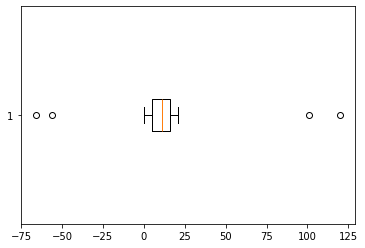

In [18]:
#boxplot method

plt.boxplot(marks, vert= False)

In [59]:
#iqr method

def detect_outliers_iqr(marks):
    outliers= []
    marks= sorted(marks)
    
    for i in range(0,len(marks)):
        if np.isnan(marks[i]):
            marks[i]=0
    print(marks)
    marks= np.array(marks)
    q1= np.percentile(marks, 25)
    q3= np.percentile(marks, 75)
    iqr= q3-q1
    lower_bound= q1-(1.5*iqr)
    upper_bound= q3+(1.5*iqr)
    for m in marks:
        if m>upper_bound:
            outliers.append(m)
        elif m< lower_bound:
            outliers.append(m)
            print(m)
            
    return outliers
    
df= pd.read_csv("/home/student/Downloads/marks.csv")
print(df['DSBDA'])
outliers= detect_outliers_iqr(df['DSBDA'])
print(outliers)

0      54.0
1      45.0
2       NaN
3      34.0
4      54.0
5       2.0
6      43.0
7      67.0
8      13.0
9      32.0
10     93.0
11      1.0
12     63.0
13     32.0
14     12.0
15     64.0
16      6.0
17     63.0
18     44.0
19     66.0
20      3.0
21     34.0
22     33.0
23   -899.0
24     64.0
Name: DSBDA, dtype: float64
[-899.0, 1.0, 2.0, 3.0, 6.0, 12.0, 13.0, 32.0, 32.0, 33.0, 34.0, 34.0, 43.0, 44.0, 45.0, 54.0, 0, 54.0, 63.0, 63.0, 64.0, 64.0, 66.0, 67.0, 93.0]
-899.0
[-899.0]


In [6]:
#z score method

def zscore_outliers(marks):
    ub= 60
    lb= 0
    
    #handling nan
    for i in range(0,len(marks)):
        if np.isnan(marks[i]):
            marks[i]=0
    mean= np.mean(marks)
    sd= np.std(marks)
    z_ub= (ub-mean)/sd
    z_lb= (lb-mean)/sd
    print("lower zscore bound:", z_lb)
    print("upper zscore bound:", z_ub)
    outliers= []
    
    for i in marks:
#         print(i)
        z_score= (i-mean)/sd
#         print(z_score)
        if(np.abs(z_score)>z_ub):
            outliers.append(i)
        elif(np.abs(z_score)<z_lb):
            outliers.append(i)
    return outliers

df= pd.read_csv("/home/student/Downloads/marks.csv")
outliers= zscore_outliers(df['DSBDA'])
print(outliers)

lower zscore bound: -0.004962449268674039
upper zscore bound: 0.31867554651441543
[67.0, 93.0, 63.0, 64.0, 63.0, 66.0, -899.0, 64.0]


/tmp/ipykernel_4846/621376050.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marks[i]=0


<Axes: xlabel='Minmax scaler', ylabel='Count'>

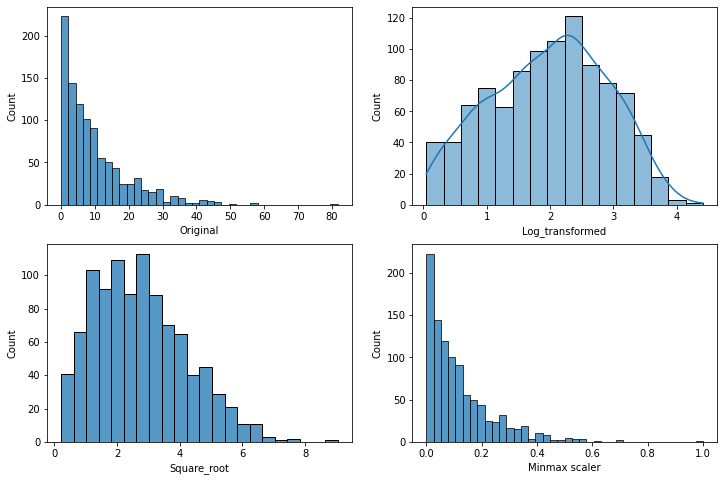

In [30]:
#Transformations

np.random.seed(42)
data= np.random.exponential(scale=10, size=1000)
df= pd.DataFrame({'Original': data})
df['Log_transformed']= np.log1p(df[['Original']])
df['Square_root']= np.sqrt(df[['Original']])
scaler= MinMaxScaler()
df['Minmax scaler']= scaler.fit_transform(df[['Original']])
# print(df)
fig, axes= plt.subplots(2,2, figsize=(12,8))
sns.histplot(df['Original'], ax= axes[0,0])
sns.histplot(df['Log_transformed'],kde= True, ax= axes[0,1])
sns.histplot(df['Square_root'], ax= axes[1,0])
sns.histplot(df['Minmax scaler'], ax= axes[1,1])
                                   